In [1]:
from pathlib import Path
from clearit.config import OUTPUTS_DIR
from clearit.metrics.gather_scatter_data import (
    prepare_scatter_dataframe_single_patient_networks,
)
from clearit.plotting.scatter import scatter_performance_vs_rank
from clearit.plotting.utils import build_single_patient_entries

# TNBC1-MxIF8

In [2]:
# Build entries
entries_b = build_single_patient_entries(
    patient_start=1,
    patient_end=47,
    test_start_id=412,
    dataset_label="TNBC1-MxIF8",
)

# Load image statistics
image_stats_b_csv = Path(
    OUTPUTS_DIR, "ranking", "TNBC1-MxIF8", "image_statistics_extended.csv"
)

In [3]:
# Prepare dataframe with ranking metrics
df_scatter_b = prepare_scatter_dataframe_single_patient_networks(
    entries_b,
    image_stats_b_csv,
)

Spearman correlations:
  Normalized_Score_std: r=0.51, p=0.00028


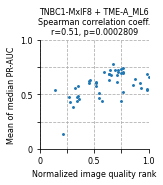

In [4]:
ax, corr_b, data_df_b = scatter_performance_vs_rank(
    df_scatter_b,
    perf_col="pr_auc",
    rank_cols=[
        "Normalized_Score_std",                    # legacy
        #"rank_total_mean_clipped_99_5",            # clipping
        #"rank_total_mean_to_median",               # mean/median
        #"rank_total_entropy",                      # entropy
        #"rank_channel_1_focus_gradient_energy",    # focus
    ],
    marker_size=3.5,
    figsize=(2.0, 2.0),
    title="TNBC1-MxIF8 + TME-A_ML6",
)

print("Spearman correlations:")
for name, (r, p) in corr_b.items():
    print(f"  {name}: r={r:.2f}, p={p:.2g}")

ax.figure.savefig("E3b.svg", dpi=300, bbox_inches="tight")
data_df_b.drop("rank_col",axis=1).to_excel("E3b.xlsx", index=False)

# TNBC2-MIBI8

In [5]:
# Build entries
entries_c = build_single_patient_entries(
    patient_start=1,
    patient_end=30,
    test_start_id=626,
    dataset_label="TNBC2-MIBI8",
)

# Load image statistics
image_stats_c_csv = Path(
    OUTPUTS_DIR, "ranking", "TNBC2-MIBI8", "image_statistics_extended.csv"
)

In [6]:
# 2) Prepare DF with extra ranking metrics
df_scatter_c = prepare_scatter_dataframe_single_patient_networks(
    entries_c,
    image_stats_c_csv,
)

Spearman correlations:
  Normalized_Score_std: r=0.92, p=1.4e-12


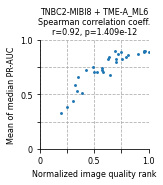

In [7]:
ax, corr_c, data_df_c = scatter_performance_vs_rank(
    df_scatter_c,
    perf_col="pr_auc",
    rank_cols=[
        "Normalized_Score_std",                    # legacy
        #"rank_total_mean_clipped_99_5",            # clipping
        #"rank_total_mean_to_median",               # mean/median
        #"rank_total_entropy",                      # entropy
        #"rank_channel_1_focus_gradient_energy",    # focus
    ],
    marker_size=3.5,
    figsize=(2.0, 2.0),
    title="TNBC2-MIBI8 + TME-A_ML6",
)

print("Spearman correlations:")
for name, (r, p) in corr_c.items():
    print(f"  {name}: r={r:.2f}, p={p:.2g}")

ax.figure.savefig("E3c.svg", dpi=300, bbox_inches="tight")
data_df_c.drop("rank_col",axis=1).to_excel("E3c.xlsx", index=False)